In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [8]:
df = pd.read_csv('./content/data/train.csv')

In [9]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [10]:
print(f'Count features with null-value = {df.isnull().any(axis=0).sum()}')

Count features with null-value = 19


Очень много фичей, много интересных мыслей появлялось в процессе анализа. Щас всё попробую. Но сначала надо избавиться от null-значений.

# Работа с null-значений
В начале анализа выяснил, что много фичей имеют много null-значений. Сначала казалось это плохо, но потом узнал, что эти null-значения показывают отсутствие данного
объекта на участке (напр, нет забора, камина и т.п.). Это не значит что данные были потеряны.\
Поэтому важно все эти null-значения заменить на что-то логично, с чем модели могут работать.

In [11]:
null_count = df.isnull().sum()
null_count[null_count > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

## LotFrontage null
Показывает ширину участка, граничащую с улицей.\
Очевидно, дом не может не граничить с улицей, т.к. какой-то подход должен к нему быть. Поэтому стоит эти значения заполнить.

Можно было бы заполнить все null-значения обычным средним, но хочется большей точности. У каждого сэмпла есть *LotConfig*, которые показывает, насколько
хорошо дом прилегает к дороге. Думаю, у домов, которые прилегают к дороге с 3-х сторон, значение *LotFrontage* будет заметно выше:

In [12]:
df.groupby('LotConfig')['LotFrontage'].mean()

LotConfig
Corner     84.039801
CulDSac    59.911111
FR2        63.515152
FR3        70.750000
Inside     67.715686
Name: LotFrontage, dtype: float64

Интересно, что угловой участок (*Corner*) имеет большее значение, чем участок, окружённый улицами с 3-х сторон (*FR3*). Но оба они всё равно имеют большее значение,
чем другие.

In [13]:
lotfrontage_null = df.groupby('LotConfig')['LotFrontage'].mean().round()

for value, mean in lotfrontage_null.items():
    df.loc[(df['LotFrontage'].isnull()) & (df['LotConfig'] == value), 'LotFrontage'] = mean

## Alley null
Показывает либо материал аллеи, либо её отсутствие. Здесь null-значение несёт важную информацию.

In [14]:
df.loc[df['Alley'].isnull(), 'Alley'] = 'Absent'

## MasVnrType null
Показывает облицовку дома. Null-значение несёт в себе информацию.

In [15]:
df.loc[df['MasVnrType'].isnull(), 'MasVnrType'] = 'Absent'

## MasVnrArea null
Показывает площадь облицовки из кирпица. Имеет 8 null-значений, хотя отсутствие облицовки должно просто обозначаться цифрой 0.

In [16]:
df[df['MasVnrArea'].isnull()][['MasVnrType', 'MasVnrArea']]

,MasVnrType,MasVnrArea
234,Absent,NaN
529,Absent,NaN
650,Absent,NaN
936,Absent,NaN
973,Absent,NaN
977,Absent,NaN
1243,Absent,NaN
1278,Absent,NaN


У null-значений облицовка отсутствует, так что можно спокойно присваивать значение 0:

In [17]:
df.loc[df['MasVnrArea'].isnull(), 'MasVnrArea'] = 0

## BsmtQual null
Показывает высоту подвала. Null-значения показывают отсутствие подвала.

In [18]:
df.loc[df['BsmtQual'].isnull(), 'BsmtQual'] = 'Absent'

## BsmtCond null
Оценивает общее состояние подвала. Null-значение показывает отсутствие подвала.

In [19]:
df.loc[df['BsmtCond'].isnull(), 'BsmtCond'] = 'Absent'

## BsmtExposure null
Показывает стену, ведущую на террасу или в сад. Т.е. насколько хорошо подвал выходит на наружу: его может быть совсем не видно, могут быть небольшие окна, из которых попадает свет,
а может быть целая дверь с выходом во двор.

У 37 домов подвалы отсутсвуют, точно будет 37 null-значений. Но есть и ещё один:

In [20]:
df[(df['BsmtExposure'].isnull()) & (df['BsmtQual'] != 'Absent')].filter(regex=r'.*Bsmt.*')

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,BsmtFullBath,BsmtHalfBath
948,Gd,TA,NaN,Unf,0,Unf,0,936,936,0,0


Видно, что подвал есть и достаточно большой. Но значения *BsmtFin\** показывают, что подвал недостроен. Поэтому фактически он есть, но невозможно использовать.\
Его тоже можно пометить как *Absent*:

In [21]:
df.loc[df['BsmtExposure'].isnull(), 'BsmtExposure'] = 'Absent'

## BsmtFinType1 null
Качество отделки основной зоны подвала. 37 null-значений. Те самые дома, у которых подвал отсутствует.

In [22]:
df.loc[df['BsmtFinType1'].isnull(), 'BsmtFinType1'] = 'Absent'

## BsmtFinType2 null
Качество отделки дополнительной зоны подвала. 38 null-значений. У 37 домов точно нет подвала. 38-й сэмпл очень интересный:

In [23]:
df[(df['BsmtFinType2'].isnull()) & (df['BsmtQual'] != 'Absent')].filter(regex=r'.*Bsmt.*')

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,BsmtFullBath,BsmtHalfBath
332,Gd,TA,No,GLQ,1124,NaN,479,1603,3206,1,0


Это какое-то потерянное значение. У данного дома есть подвал, от отделан, достаточно хорошая площадь. Даже видно, что дополнительная зона подвала готова
к использованию (судя по *BsmtFinSF2*), но при этом значение *BsmtFinType2* отсутствует. Заполним его самым популярным значением в *BsmtFinType2*:

In [24]:
df['BsmtFinType2'].value_counts()

BsmtFinType2
Unf    1256
Rec      54
LwQ      46
BLQ      33
ALQ      19
GLQ      14
Name: count, dtype: int64

Самое популярное значение *Unf*, но мы видим, что дополнительная зона подвала точно готова к использованию. Использую лучше значение *Rec*:

In [25]:
df.loc[(df['BsmtFinType2'].isnull()) & (df['BsmtFinSF2'] > 0), 'BsmtFinType2'] = 'Rec'
df.loc[df['BsmtFinType2'].isnull(), 'BsmtFinType2'] = 'Absent'

## Electrical null
Показывает тип электрической системы.

In [26]:
df[df['Electrical'].isnull()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1379,1380,80,RL,73.0,9735,Pave,Absent,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,167500


Ничего необычного, заполню самым частым значением:

In [27]:
df['Electrical'].value_counts()

Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: count, dtype: int64

In [28]:
df.loc[df['Electrical'].isnull(), 'Electrical'] = 'SBrkr'

## FireplaceQu null
Показывает качество каминов. Null-значение показывает отсутствие камина в доме.

Проверим сэмплы, у которых качество камина имеет null-значение, а количество каминов > 0:

In [29]:
df[(df['FireplaceQu'].isnull()) & (df['Fireplaces'] > 0)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


В датасете отсутствуют подобные сэмплы, можно спокойно обозначать *Absent*:

In [30]:
df.loc[df['FireplaceQu'].isnull(), 'FireplaceQu'] = 'Absent'

## Garage* null
За гараж отвечают признаки *GarageType*, *GarageYrBlt*, *GarageFinist*, *GarageQual* и *GarageCond*.\
Каждый из них имеет 81 null-значений. Они показывают отсутствие гаража. Совпадение null-значений в каждом признаки показывает отсутствие пропусков.

In [31]:
df.loc[df['GarageType'].isnull() , 'GarageType'] = 'Absent'
df.loc[df['GarageFinish'].isnull() , 'GarageFinish'] = 'Absent'
df.loc[df['GarageQual'].isnull() , 'GarageQual'] = 'Absent'
df.loc[df['GarageCond'].isnull() , 'GarageCond'] = 'Absent'

И с фичой *GarageYrBlt* получается неоднозначная ситуация: столбец содержит числа (float64), однако при отсутствии гаража стоит
null-значение. Изменить на *Absent* не получится.\
Если подобрать какое-то определённое число для null-значений (напр, 0 или год постройки дома), разные модели могут неправильно
обучаться на них.

Думаю, хорошим вариантом будет изменить *GarageYrBlt* на возраст гаража *GarageAge*, а для наличия гаража использовать
новую фичу *HasGarage*:

In [32]:
df['GarageAge'] = (df['YrSold'] - df['GarageYrBlt'])
df['GarageAge'] = df['GarageAge'].fillna(0)
df['GarageAge'] = df['GarageAge'].astype(int)

df['HasGarage'] = (df['GarageArea'] > 0).astype(int)

df = df.drop(columns='GarageYrBlt')

## PoolQC null
Показывает качество бассейна. Null-значение показывает отсутствие бассейна.

In [33]:
df.loc[df['PoolQC'].isnull(), 'PoolQC'] = 'Absent'

## Fence null
Показывает качество забора. Null-значение показывает отсутствие забора.

In [34]:
df.loc[df['Fence'].isnull(), 'Fence'] = 'Absent'

## MiscFeature null
Показывает наличие дополнительного функционала, которые не вошёл в основные фичи. Есть ещё фича *MiscValue*, которая показывает стоимость этого функционала.

Думаю, нет смысла указывать что за объект стоит на участке, если его ценность уже указана в *MiscValue*. А объкты, у которых нет ничего дополнительного, имеют
*MiscValue* = 0, что и показывает отсутствие каких-либо доп.объектов на участке.

Осталю на данные момент этот столбец, а при фича-инженеринге удалю:

# Преобразование фичей
_UPD 1_: Я тут щас преобразовывал фичи из категориальных в ординальные и понял, что не всем моделям подойдёт ординальное кодирование.
Линейным моделям (а следовательно, и нейросетям) лучше делать _one-hot-encoding_. Благо для этого есть _.get_dummies()_.\
Поэтому я продолжу здесь делать заготовки для _ordinal-encoding_, который пойдёт потом в пайплайн, но итоговое преобразование
будет зависить от модели.

*UPD 2*: При реализации *Ordinal-encoding* значения отсортированы с помощью вещественные чисел. Т.е. значимость признаков идёт не
\[$1, 2, 3, \dots$], а \[$1, 2.5, 4.5, \dots$]. Это было сделано чтобы не просто расположить их в порядке возрастания ценности,
но и чтобы обозначить моделям, насколько выростает значимость у каждого значения.

*UPD 3*: Все реализации *Target-encoding* пошли коту под хвост, ибо я всё равно использу встроенный класс *TargetEncoder*.

 ## MSSubClass fe
Признак содержит числа, обозначающие какой-то тип дома. Расположены в следующем порядке:
- 20  — 1-STORY 1946 & NEWER ALL STYLES
- 30  — 1-STORY 1945 & OLDER
- 40  — 1-STORY W/FINISHED ATTIC ALL AGES
- 45  — 1-1/2 STORY - UNFINISHED ALL AGES
- 50  — 1-1/2 STORY FINISHED ALL AGES
- 60  — 2-STORY 1946 & NEWER
- 70  — 2-STORY 1945 & OLDER
- 75  — 2-1/2 STORY ALL AGES
- 80  — SPLIT OR MULTI-LEVEL
- 85  — SPLIT FOYER
- 90  — DUPLEX - ALL STYLES AND AGES
- 120 — 1-STORY PUD (Planned Unit Development) - 1946 & NEWER
- 150 — 1-1/2 STORY PUD - ALL AGES
- 160 — 2-STORY PUD - 1946 & NEWER
- 180 — PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
- 190 — 2 FAMILY CONVERSION - ALL STYLES AND AGES

Но возрастание числа не соответствует росту ценности дома.\
Можно было бы щтательно исследовать данную тему в интернете и поставить дома в возрастании в соответствии с данными. Но будет проще найти среднюю стоимость каждого дома и
расположить их в порядке возрастания средней стоимости дома:

In [35]:
df.groupby('MSSubClass', as_index=False)['SalePrice'].mean().sort_values('SalePrice')

,MSSubClass,SalePrice
1,30,95829.724638
13,180,102300.000000
3,45,108591.666667
14,190,129613.333333
10,90,133541.076923
12,160,138647.380952
4,50,143302.972222
9,85,147810.000000
2,40,156125.000000
6,70,166772.416667


In [36]:
df['MSSubClass_Rating'] = 0

mssubclass_sorted = df.groupby('MSSubClass', as_index=False)['SalePrice'].mean().sort_values('SalePrice')

for idx, mssubclass in enumerate(mssubclass_sorted['MSSubClass']):
    df.loc[df['MSSubClass'] == mssubclass, 'MSSubClass_Rating'] = idx + 1

Проверим правильность сортировки:

In [37]:
table_old = df.groupby('MSSubClass', as_index=False)['SalePrice'].mean().sort_values('SalePrice').reset_index(drop=True)
table_new = df.groupby('MSSubClass_Rating', as_index=False)['SalePrice'].mean().sort_values('SalePrice').reset_index(drop=True)
pd.concat([table_old, table_new], axis=1)

,MSSubClass,SalePrice,MSSubClass_Rating,SalePrice
0,30,95829.724638,1,95829.724638
1,180,102300.000000,2,102300.000000
2,45,108591.666667,3,108591.666667
3,190,129613.333333,4,129613.333333
4,90,133541.076923,5,133541.076923
5,160,138647.380952,6,138647.380952
6,50,143302.972222,7,143302.972222
7,85,147810.000000,8,147810.000000
8,40,156125.000000,9,156125.000000
9,70,166772.416667,10,166772.416667


In [38]:
df = df.drop(columns='MSSubClass')

## MSZoning fe
Показывает градостроительное назначение земли.

В данном признаке 8 значений, но в обучаемых данных используется лишь 5. Если модель увидит какое-то новое значение на проде, предсказание
от этого лучше не станет. Но и выдавать ему значение другой группы тоже не справедливо. Буду присвать ему среднее значение, если
кодировка будет с помощью *Ordinal-encoding*. Порядок в данной кодировке (из EDA): *C (all)* < *RH* < *RM* < *RL* < *FV*.

А вообще, для данного признака лучше всего выглядит *One-hot-encoding*.

In [39]:
df['MSZoning_Rating'] = 2.5 # Сразу присваиваю значение по умолчанию

df.loc[df['MSZoning'] == 'C (all)', 'MSZoning_Rating'] = 1
df.loc[df['MSZoning'] == 'RH', 'MSZoning_Rating'] = 2
df.loc[df['MSZoning'] == 'RM', 'MSZoning_Rating'] = 3
df.loc[df['MSZoning'] == 'RL', 'MSZoning_Rating'] = 4
df.loc[df['MSZoning'] == 'FV', 'MSZoning_Rating'] = 5

df = df.drop(columns='MSZoning')

## Street fe
Показывает материал дороги улицы, из которого она сделана.

В датасете 1460 сэмплов, 6 из который имеют значение *Grvl*, остальные — *Pave*. Признак явлется квазиконстантным. Следует удалить:

In [40]:
df = df.drop(columns='Street')

## Alley fe
Показывает материал аллеи, из которого она сделана.

Посчитаем среднюю цену дома с разным типом алей:

In [41]:
df.groupby('Alley')['SalePrice'].mean()

Alley
Absent    183452.131483
Grvl      122219.080000
Pave      168000.585366
Name: SalePrice, dtype: float64

При отсутствии аллеи дом стоит в среднем 183к$. Дома с твёрдой аллеей стоят дороже чем с рассыпчатой. Но домов с аллей в принципе мало: всего 91 штука (примерно 7% от всего датасета).
Более интересен сам факт наличия данной аллеи: дома без аллеи стоят, 183к\\$, а с аллеей — 145к\\$. Разница ощутима.\
Поменяю фичу *Alley* на *Has_Alley*, которая будет показывать факт наличия аллеи у дома:

In [42]:
df['Has_Alley'] = (df['Alley'] != 'Absent').astype(int)

df = df.drop(columns='Alley')

## LotShape fe
Общая форма объекта недвижимости. Показывает рост цен от *Reg* до *IR2*, а на *IR3* резкое падение.

*Ordinal-encoding* не подойдёт. В идеале будет использовать *One-hot-encoding*, но столбцы *IR2* и *IR3* будут сильно разреженными.\
Сейчас просто закодирую с помощью *Target-encoding*:

In [43]:
df['LotShape_Target'] = 0

lotshape_target = df.groupby('LotShape')['SalePrice'].mean()

for lotshape, target_mean in lotshape_target.items():
    df.loc[df['LotShape'] == lotshape, 'LotShape_Target'] = round(target_mean)

df = df.drop(columns='LotShape')

## LandContour fe
Показывает рельеф земельного участка.

In [44]:
df['LandContour_Rating'] = 0.0

df.loc[df['LandContour'] == 'Bnk', 'LandContour_Rating'] = 1
df.loc[df['LandContour'] == 'Lvl', 'LandContour_Rating'] = 3
df.loc[df['LandContour'] == 'Low', 'LandContour_Rating'] = 4.5
df.loc[df['LandContour'] == 'HLS', 'LandContour_Rating'] = 6

df = df.drop(columns='LandContour')

## Utilities fe
Показывает виды доступных коммунальных услуг. Все сэмплы имеют значение *AllPub*, лишь один значение *NoSeWa* — отсутствие воды и канализации.

Признак является квазиконстантным. Следует удалить:

In [45]:
df = df.drop(columns='Utilities')

## LotConfig fe
Конфигурация участка. В принципе, сэмплов каждого значения достаточно для обучения, но значение *FR3* содержит всего-лишь 4 сэмпла. Очень мало для выделения в одну категорию.
Но удалять эти 4 сэмпла тоже не лучший вариант. Лучше объединить их с *FR2* в одну категорию:

In [46]:
df['LotConfig'] = df['LotConfig'].replace(['FR2', 'FR3'], 'FR')

df['LotConfig_Rating'] = 0.0

df.loc[df['LotConfig'] == 'Inside', 'LotConfig_Rating'] = 1
df.loc[df['LotConfig'] == 'FR', 'LotConfig_Rating'] = 1.25
df.loc[df['LotConfig'] == 'Corner', 'LotConfig_Rating'] = 1.5
df.loc[df['LotConfig'] == 'CulDSac', 'LotConfig_Rating'] = 3.5

df = df.drop(columns='LotConfig')

## LandSlope fe
Наклон участка. Значение *Sev* содержит всего-лишь 13 значений. Мало для обучения.

Посмотрим на среднюю цену дома в зависимости от наклона участка:

In [47]:
df.groupby('LandSlope')['SalePrice'].mean()

LandSlope
Gtl    179956.799566
Mod    196734.138462
Sev    204379.230769
Name: SalePrice, dtype: float64

Значения *Mod* и *Sev* оба обозначают наклон участка. Лучше объединить их в одну группу:

In [48]:
df['LandSlope'] = df['LandSlope'].replace(['Sev', 'Mod'], 'Sloped')

df['LandSlope_Rating'] = 0.0

df.loc[df['LandSlope'] == 'Gtl', 'LandSlope_Rating'] = 1
df.loc[df['LandSlope'] == 'Sloped', 'LandSlope_Rating'] = 4

df = df.drop(columns='LandSlope')

## Neighborhood fe
Район расположения участка. В EDA уже разделил его на классы, которые показывают отличную корреляцию.\
Только там были указаны классы *Highest*, *High*, *Medium*, *Low* и *Lowest*. Надо их передалать в числовые признаки:

In [49]:
highest_neighborhood = ['NoRidge', 'NridgHt', 'StoneBr']
high_neighborhood = ['Timber', 'Veenker', 'Somerst', 'ClearCr', 'Crawfor']
medium_neighborhood = ['CollgCr', 'Blmngtn', 'NWAmes', 'SawyerW', 'Gilbert', 'Mitchel', 'NPkVill', 'NAmes']
low_neighborhood = ['Sawyer', 'SWISU', 'Blueste', 'BrkSide', 'Edwards', 'OldTown', 'BrDale']
lowest_neighborhood = ['IDOTRR', 'MeadowV']

df['Neighborhood_Rating'] = 5.9 # Среднее значение по умолчанию

df.loc[df['Neighborhood'].isin(lowest_neighborhood), 'Neighborhood_Rating'] = 1
df.loc[df['Neighborhood'].isin(low_neighborhood), 'Neighborhood_Rating'] = 2.5
df.loc[df['Neighborhood'].isin(medium_neighborhood), 'Neighborhood_Rating'] = 5
df.loc[df['Neighborhood'].isin(high_neighborhood), 'Neighborhood_Rating'] = 7
df.loc[df['Neighborhood'].isin(highest_neighborhood), 'Neighborhood_Rating'] = 12

df = df.drop(columns='Neighborhood')

## Condition1 fe
Близость к объектам инфраструктуры.

Разбиение уже сделал в EDA, осталось только перевести в числа:

In [50]:
good_condition1 = ['PosN', 'PosA', 'RRNn', 'RRNe']
normal_condition1 = ['Norm', 'RRAn']
poor_condition1 = ['Feedr', 'Artery', 'RRAe']

df['Condition1_Rating'] = 0.0

df.loc[df['Condition1'].isin(poor_condition1), 'Condition1_Rating'] = 1
df.loc[df['Condition1'].isin(normal_condition1), 'Condition1_Rating'] = 4.5
df.loc[df['Condition1'].isin(good_condition1), 'Condition1_Rating'] = 7

df = df.drop(columns='Condition1')

## Condition2 fe
Аналогично *Condition1*:

In [51]:
good_condition2 = ['PosN', 'PosA', 'RRNn', 'RRNe']
normal_condition2 = ['Norm', 'RRAn']
poor_condition2 = ['Feedr', 'Artery', 'RRAe']

df['Condition2_Rating'] = 0.0

df.loc[df['Condition2'].isin(poor_condition2), 'Condition2_Rating'] = 1
df.loc[df['Condition2'].isin(normal_condition2), 'Condition2_Rating'] = 2.5
df.loc[df['Condition2'].isin(good_condition2), 'Condition2_Rating'] = 4

df = df.drop(columns='Condition2')

## BldgType fe
Тип жилища.

In [52]:
df['BldgType_Rating'] = 0.0

df.loc[df['BldgType'] == '2fmCon', 'BldgType_Rating'] = 1
df.loc[df['BldgType'] == 'Duplex', 'BldgType_Rating'] = 1.25
df.loc[df['BldgType'] == 'Twnhs', 'BldgType_Rating'] = 1.5
df.loc[df['BldgType'] == 'TwnhsE', 'BldgType_Rating'] = 4.25
df.loc[df['BldgType'] == '1Fam', 'BldgType_Rating'] = 4.5

df = df.drop(columns='BldgType')

## HouseStyle fe
Архитектурная конфигурация дома. 8 значений. Достаточно много, хочется их уменьшить. В данном случае есть такая возможность:
- *2.5Unf* и *2.5Fin* можно объединить в 2.5-этажные дома *2.5Story*;
- *1.5Unf* и *1.5Fin* можно объединить в 1.5-этажные дома *1.5Story*;
- Разделённый дома *SFoyer* и *SLvl* можно объединить в просто распиленный дома *Split*.

In [53]:
df['HouseStyle'] = df['HouseStyle'].replace(['2.5Unf', '2.5Fin'], '2.5Story')
df['HouseStyle'] = df['HouseStyle'].replace(['1.5Unf', '1.5Fin'], '1.5Story')
df['HouseStyle'] = df['HouseStyle'].replace(['SFoyer', 'SLvl'], 'Split')

df['HouseStyle_Rating'] = 0.0

df.loc[df['HouseStyle'] == '1.5Story', 'HouseStyle_Rating'] = 1
df.loc[df['HouseStyle'] == 'Split', 'HouseStyle_Rating'] = 2
df.loc[df['HouseStyle'] == '1Story', 'HouseStyle_Rating'] = 4
df.loc[df['HouseStyle'] == '2.5Story', 'HouseStyle_Rating'] = 4.5
df.loc[df['HouseStyle'] == '2Story', 'HouseStyle_Rating'] = 6.5

df = df.drop(columns='HouseStyle')

## RoofStyle fe
Тип крыши.

Самые поплярные типы крыш: *Gable*, *Hip*. Остальных очень мало, стоит объединить в одну группу:

In [54]:
df['RoofStyle'] = df['RoofStyle'].replace(['Gambrel', 'Mansard', 'Flat', 'Shed'], 'Rare')

df['RoofStyle_Rating'] = 0.0

df.loc[df['RoofStyle'] == 'Gable', 'RoofStyle_Rating'] = 1
df.loc[df['RoofStyle'] == 'Rare', 'RoofStyle_Rating'] = 1.5
df.loc[df['RoofStyle'] == 'Hip', 'RoofStyle_Rating'] = 3.5

df = df.drop(columns='RoofStyle')

## RoofMatl fe
Материал крыши.

Самый поплярный — битумная черепица *CompShg*. Остальных очень мало, стоит объединить в одну группу:

In [55]:
df['RoofMatl'] = df['RoofMatl'].replace(['ClyTile', 'Membran', 'Metal', 'Roll', 'Tar&Grv', 'WdShake', 'WdShngl'], 'Rare')

df['RoofMatl_Rating'] = 0.0

df.loc[df['RoofMatl'] == 'CompShg', 'RoofMatl_Rating'] = 1
df.loc[df['RoofMatl'] == 'Rare', 'RoofMatl_Rating'] = 7

df = df.drop(columns='RoofMatl')

## Exterior1st fe
Внешняя отделка дома.

Много всяких значений и мало сэмплов. В EDA уже объединил в группы:

In [56]:
df['Exterior1st_Rating'] = 0.0

outdated_exterior1st = ['AsbShng', 'BrkComm', 'AsphShn', 'CBlock', 'BrkComm', 'PreCast', 'Other']
wooden_exterior1st = ['Wd Sdng', 'Plywood', 'WdShing']
standart_exterior1st = ['VinylSd', 'MetalSd', 'HdBoard']
premium_exterior1st = ['BrkFace', 'Stone', 'CemntBd', 'Stucco', 'ImStucc']

df.loc[df['Exterior1st'].isin(outdated_exterior1st), 'Exterior1st_Rating'] = 1
df.loc[df['Exterior1st'].isin(wooden_exterior1st), 'Exterior1st_Rating'] = 3.5
df.loc[df['Exterior1st'].isin(standart_exterior1st), 'Exterior1st_Rating'] = 4
df.loc[df['Exterior1st'].isin(premium_exterior1st), 'Exterior1st_Rating'] = 5

df = df.drop(columns='Exterior1st')

## Exterior2nd fe
Аналогично *Exterior1st*:

In [57]:
df['Exterior2nd_Rating'] = 0.0

outdated_exterior2st = ['AsbShng', 'BrkComm', 'AsphShn', 'CBlock', 'BrkComm', 'PreCast', 'Other']
wooden_exterior2st = ['Wd Sdng', 'Plywood', 'WdShing']
standart_exterior2st = ['VinylSd', 'MetalSd', 'HdBoard']
premium_exterior2st = ['BrkFace', 'Stone', 'CemntBd', 'Stucco', 'ImStucc']

df.loc[df['Exterior2nd'].isin(outdated_exterior2st), 'Exterior2nd_Rating'] = 1
df.loc[df['Exterior2nd'].isin(wooden_exterior2st), 'Exterior2nd_Rating'] = 3.5
df.loc[df['Exterior2nd'].isin(standart_exterior2st), 'Exterior2nd_Rating'] = 4
df.loc[df['Exterior2nd'].isin(premium_exterior2st), 'Exterior2nd_Rating'] = 5

df = df.drop(columns='Exterior2nd')

## MasVnrType fe
Декоративная облицовка дома.

Значение *CBlock* отсутствует в тренировочных сэмплах, установлю для него значение по умолчанию:

In [58]:
df['MasVnrType_Rating'] = 2.75 # Значение по умолчанию

df.loc[df['MasVnrType'] == 'BrkCmn', 'MasVnrType_Rating'] = 1
df.loc[df['MasVnrType'] == 'Absent', 'MasVnrType_Rating'] = 1.5
df.loc[df['MasVnrType'] == 'BrkFace', 'MasVnrType_Rating'] = 3
df.loc[df['MasVnrType'] == 'Stne', 'MasVnrType_Rating'] = 5.5

df = df.drop(columns='MasVnrType')

## ExterQual fe
Качество материала внешней отделки.

Сэмплы со значением *Poor* вообще отсутствуют, а *Fair* всего-лишь 14 штук, что составляет <1% от данных. При этом, *Poor* и *Fair* являются смежными признаками.
Следует их объединить:

In [59]:
df['ExterQual_Rating'] = 1.0 # Сразу объединяю и присваиваю значение для Poor & Fair

df.loc[df['ExterQual'] == 'TA', 'ExterQual_Rating'] = 2.5
df.loc[df['ExterQual'] == 'Gd', 'ExterQual_Rating'] = 5
df.loc[df['ExterQual'] == 'Ex', 'ExterQual_Rating'] = 9

df = df.drop(columns='ExterQual')

## ExterCond fe
Оценивает текущее состояние внешнего материала внешней отделки.

Очень мало сэмплов для значений *Excellent* и *Poor*. Стоит объединить *Poor* и *Fair*, а также *Good* и *Excellent*:

In [60]:
low_extercond = ['Po', 'Fa']
medium_extercond = ['TA']
high_extercond = ['Gd', 'Ex']

df['ExterCond_Rating'] = 0.0

df.loc[df['ExterCond'].isin(low_extercond), 'ExterCond_Rating'] = 1
df.loc[df['ExterCond'].isin(medium_extercond), 'ExterCond_Rating'] = 3
df.loc[df['ExterCond'].isin(high_extercond), 'ExterCond_Rating'] = 3.5

df = df.drop(columns='ExterCond')

## Foundation fe
Тип фундамента.

Значений *Wood*, *Stone* и *Slab* очень мало. Объединю их в один:

In [61]:
rare_foundation = ['Wood', 'Stone', 'Slab']
df.loc[df['Foundation'].isin(rare_foundation), 'Foundation'] = 'Rare'

df['Foundation_Rating'] = 0.0

df.loc[df['Foundation'] == 'Rare', 'Foundation_Rating'] = 1
df.loc[df['Foundation'] == 'BrkTil', 'Foundation_Rating'] = 1.5
df.loc[df['Foundation'] == 'CBlock', 'Foundation_Rating'] = 3
df.loc[df['Foundation'] == 'PConc', 'Foundation_Rating'] = 6.5

df = df.drop(columns='Foundation')

## BsmtQual fe
Высота подвала.

Имеет 6 значений, в тренировочных данных отсутствует значение *Poor*. Данное значение близко к *Fair*, поэтому если в новых данных попадётся *Poor*, назначу ему значение *Fair*:

In [62]:
df['BsmtQual_Rating'] = 1.5 # Значение по умолчанию для Poor

df.loc[df['BsmtQual'] == 'Absent', 'BsmtQual_Rating'] = 1
df.loc[df['BsmtQual'] == 'Fa', 'BsmtQual_Rating'] = 1.5
df.loc[df['BsmtQual'] == 'TA', 'BsmtQual_Rating'] = 3.5
df.loc[df['BsmtQual'] == 'Gd', 'BsmtQual_Rating'] = 5.5
df.loc[df['BsmtQual'] == 'Ex', 'BsmtQual_Rating'] = 12.5

df = df.drop(columns='BsmtQual')

## BsmtCond fe
Общее состояние подвала.

Значения *Excellent* отсутствует. Значения *Poor* недостаточно. Если в новых данных попадётся *Excellent*, будет иметь такое же значение как *Good*, а *Poor* будет иметь такое же
значение как *Fair*:

In [63]:
df['BsmtCond_Rating'] = 0.0

df.loc[df['BsmtCond'] == 'Absent', 'BsmtCond_Rating'] = 1
df.loc[df['BsmtCond'] == 'Po', 'BsmtCond_Rating'] = 2
df.loc[df['BsmtCond'] == 'Fa', 'BsmtCond_Rating'] = 2
df.loc[df['BsmtCond'] == 'TA', 'BsmtCond_Rating'] = 6
df.loc[df['BsmtCond'] == 'Gd', 'BsmtCond_Rating'] = 8
df.loc[df['BsmtCond'] == 'Ex', 'BsmtCond_Rating'] = 8

df = df.drop(columns='BsmtCond')

## BsmtExposure fe
Показывает стену, ведущую на террасу или в сад.

In [64]:
df['BsmtExposure_Rating'] = 0.0

df.loc[df['BsmtExposure'] == 'Absent', 'BsmtExposure_Rating'] = 1
df.loc[df['BsmtExposure'] == 'No', 'BsmtExposure_Rating'] = 4
df.loc[df['BsmtExposure'] == 'Mn', 'BsmtExposure_Rating'] = 5.5
df.loc[df['BsmtExposure'] == 'Av', 'BsmtExposure_Rating'] = 6
df.loc[df['BsmtExposure'] == 'Gd', 'BsmtExposure_Rating'] = 8.5

df = df.drop(columns='BsmtExposure')

## BsmtFinType1 + BsmtFinSF1 + BsmtFinType2 + BsmtFinSF2 + BsmtUnfSF + TotalBsmtSF fe
Все эти фичи обозначают характеристики подвала. *BsmtFinSF1* + *BsmtFinSF2* + *BsmtUnfSF* = *TotalBsmtSF*, т.е. данные фичи образуют мультиколлинеарность. Фича *BsmtFinType2*
не имеет никаких корреляция, значения пляшут, установить зависмость невозможно.

Лучше всего сделать:
- От *BsmtFinSF1*, *BsmtFinSF2*, *BsmtUnfSF* избавиться, оставить только общую площадь подвала *TotalBsmtSF*;
- От *BsmtFinType2* избавиться, об условиях подвала будет говорить чисто *BsmtFinType1* (его обозначить просто как *BsmtFinType* и переделать с помощь *Target-encoding*);
- Сделать новую фичу *BsmtFinSF_Ratio*, которая показывают доля подвала с готовым ремонтом (При этом
надо не забыть учесть случаи домов, где подвала нет \[чтобы не было деления на 0])

In [65]:
df['BsmtFinType_Target'] = 0

lotshape_target = df.groupby('BsmtFinType1')['SalePrice'].mean()

for bsmtfintype1, target_mean in lotshape_target.items():
    df.loc[df['BsmtFinType1'] == bsmtfintype1, 'BsmtFinType_Target'] = round(target_mean)

In [66]:
df['BsmtFinSF_Ratio'] = np.where(df['TotalBsmtSF'] > 0,
                                 (df['BsmtFinSF1'] + df['BsmtFinSF2']) / df['TotalBsmtSF'],
                                 0)
df['BsmtFinSF_Ratio'] = round(df['BsmtFinSF_Ratio'], 1)

df = df.drop(columns=['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'BsmtFinType1', 'BsmtFinType2'])

## Heating fe
Тип отопления.

Очень мало сэмплов во всех значениях, кроме *GasA*, которые является абсолютным стандартом в наше время. Всё остальное является устаревшим и снижает цену дома. Лучше объединить все
значения НЕ *GasA* в один и создать новый признак *IsStandartHeating*:

In [67]:
df['IsStandartHeating'] = (df['Heating'] == 'GasA').astype(int)

df = df.drop(columns='Heating')

## HeatingQC fe
Качество и условия отопления.

Всего 1 сэмпл со значением *Poor*. Очень мало для обучения, но если взглянуть на данный сэмпл подробнее:

In [68]:
df[df['HeatingQC'] == 'Po']

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,TotalBsmtSF,HeatingQC,...,ExterQual_Rating,ExterCond_Rating,Foundation_Rating,BsmtQual_Ratin,BsmtQual_Rating,BsmtCond_Rating,BsmtExposure_Rating,BsmtFinType_Target,BsmtFinSF_Ratio,IsStandartHeating
325,326,50.0,5000,5,6,1941,1950,0.0,720,Po,...,2.5,3.0,3.0,1.5,3.5,6.0,6.0,149494,0.2,1


Видно, что дом действительно старый и поравдывают своё цену. На графике видно, что цена домов *Poor* заметно ниже *Fair* и объединять их — значить необоснованно понижать цену домов
*Fair*. Да, в *Poor* сэмпл всего-лишь один и обычно это плохо, но в данной ситуации он действительно подтвреждает своё качество. В *Ordinal-encoding* его наличие оправданно:

In [69]:
df['HeatingQC_Rating'] = 0.0

df.loc[df['HeatingQC'] == 'Po', 'HeatingQC_Rating'] = 1
df.loc[df['HeatingQC'] == 'Fa', 'HeatingQC_Rating'] = 6.5
df.loc[df['HeatingQC'] == 'TA', 'HeatingQC_Rating'] = 9
df.loc[df['HeatingQC'] == 'Gd', 'HeatingQC_Rating'] = 11
df.loc[df['HeatingQC'] == 'Ex', 'HeatingQC_Rating'] = 19

df = df.drop(columns='HeatingQC')

## CentralAir fe
Центральный кондиционер.

In [70]:
df['CentralAir'] = (df['CentralAir'] == 'Y').astype(int)

## Electrical fe
Электическая система.

Стандартом является *SBrkr*, остальные в очень малом количестве. Я в EDA разедялял на группы, но в группе *Poor* всё равно очень мало сэмплов (4 шт). Лучше объидинить вообще всё,
что не *SBrkr* в одно.\
Для этого создам новый признак *IsStandartElectrical*:

In [71]:
df['IsStandartElectrical'] = (df['Electrical'] == 'SBrkr').astype(int)

df = df.drop(columns='Electrical')

## 1stFlrSF + 2ndFlrSF + LowQualFinSF + GrLivArea fe
Все эти 4 признака обозначают наземную площадь жилого помещения. Математически это *1stFlrSF* + *2ndFlrSF* + *LowQualFinSF* =
 *GrLivArea*, что обозначает мультиколлинеарность в данных.
При этом во время покупки важна не площадь 1-го и 2-го этажей, а само их наличие и общая площадь.

Лучше всего избавиться от признаков *1stFlrSF*, *2ndFlrSF*, и *LowQualFinSF*, а размер 1-го и 2-го этажей выразить в отношении
*1stFlr_Ratio* = *1stFlrSF* / *GrLivArea*:

In [72]:
df['1stFlr_Ratio'] = round(df['1stFlrSF'] / df['GrLivArea'], 1)

df = df.drop(columns=['1stFlrSF', '2ndFlrSF', 'LowQualFinSF'])

## BsmtFullBath + BsmtHalfBath + FullBath + HalfBath fe
Все фичи показывают количество ванных и туалетных комнат в подвалах и в доме. У всех очень нестабильный график, у которых нет зависимостей. Найти связь очень сложно.

Проще объединить все эти фичи в одну *TotalBaths*, которая показывает количество ванных и туалето в доме. Зависимость всё равно будет сложная у этой фичи. Лучше её обрабатывать
с помощью *One-hot-encoding*. Здесь я её преобразую с помощью *Target-encoding*:

In [73]:
df['TotalBaths'] = df['BsmtFullBath'] + 0.5*df['BsmtHalfBath'] + df['FullBath'] + 0.5*df['HalfBath']

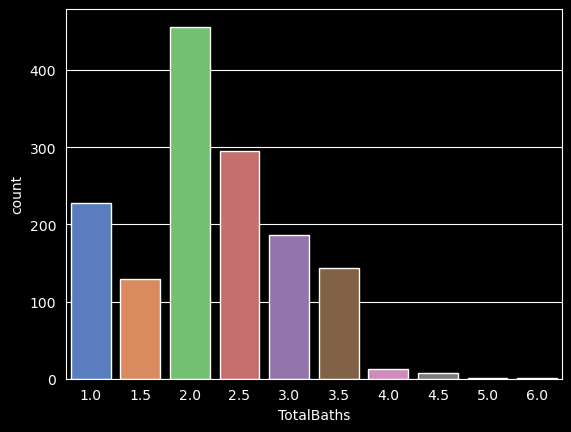

In [74]:
sns.countplot(data=df, x='TotalBaths', palette='muted')
plt.show()

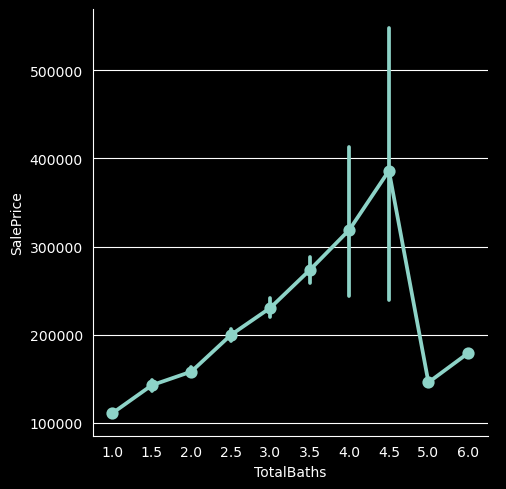

In [75]:
sns.catplot(data=df,
            x='TotalBaths',
            y='SalePrice',
            kind='point')
plt.show()

In [76]:
df['TotalBaths_Target'] = 0

totalbaths_target = df.groupby('TotalBaths')['SalePrice'].mean()

for totalbaths, target_mean in totalbaths_target.items():
    df.loc[df['TotalBaths'] == totalbaths, 'TotalBaths_Target'] = round(target_mean)

df = df.drop(columns=['BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'TotalBaths'])

## BedroomAbvGr fe
Количество спальных комнат (без учёта подвала).

Очень мало сэмплов со значениями 0, 6 и 8. Объединю их с ближайшими соседями.\
График нелинейный, установить зависимость очень сложно. В идеале преобразовать с помощью *One-hot-encoding*. Здесь преобразую с помощью *Target-encoding*:

In [77]:
df.loc[df['BedroomAbvGr'] == 0, 'BedroomAbvGr'] = 1
df.loc[df['BedroomAbvGr'] > 5, 'BedroomAbvGr'] = 5

In [78]:
df['BedroomAbvGr_Target'] = 0

bedroomabvgr_target = df.groupby('BedroomAbvGr')['SalePrice'].mean()

for bedroomabvgr, target_mean in bedroomabvgr_target.items():
    df.loc[df['BedroomAbvGr'] == bedroomabvgr, 'BedroomAbvGr_Target'] = round(target_mean)

df = df.drop(columns='BedroomAbvGr')

## KitchenAbvGr fe
Количество кухонь (без учёта подвала).

Очень мало сэмплов со значениями 0 и 3. Объединю их с ближайшими значениями:

In [79]:
df.loc[df['KitchenAbvGr'] == 0, 'KitchenAbvGr'] = 1
df.loc[df['KitchenAbvGr'] > 2, 'KitchenAbvGr'] = 2

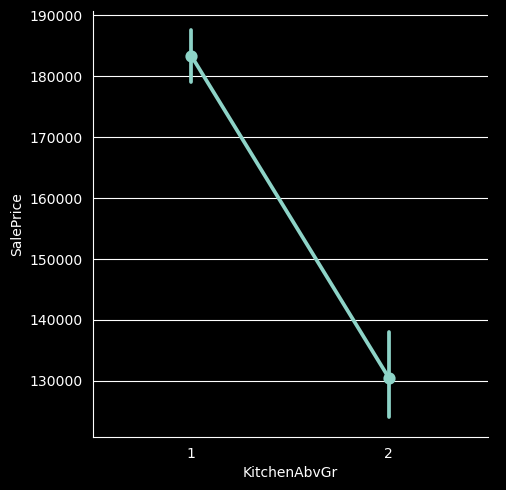

In [80]:
sns.catplot(data=df,
            x='KitchenAbvGr',
            y='SalePrice',
            kind='point')
plt.show()

Стабильное падение цены при увеличении кухонь:

In [81]:
df['KitchenAbvGr_Rating'] = 0

df.loc[df['KitchenAbvGr'] == 1, 'KitchenAbvGr_Rating'] = 6
df.loc[df['KitchenAbvGr'] == 2, 'KitchenAbvGr_Rating'] = 1

df = df.drop(columns='KitchenAbvGr')

## KitchenQual fe
Качество кухни.

Отсутствует значение *Poor*. Объединю его с ближайшим значением *Fair*:

In [82]:
df['KitchenQual_Rating'] = 0.0

df.loc[df['KitchenQual'].isin(['Po', 'Fa']), 'KitchenQual_Rating'] = 1
df.loc[df['KitchenQual'] == 'TA', 'KitchenQual_Rating'] = 3.5
df.loc[df['KitchenQual'] == 'Gd', 'KitchenQual_Rating'] = 6
df.loc[df['KitchenQual'] == 'Ex', 'KitchenQual_Rating'] = 11

df = df.drop(columns='KitchenQual')

## TotRmsAbvGrd fe
Общее количество комнат над уровнем земли (не включая ванные комнаты).

Мало сэмплов со значениями 2, 12 и 14. Объединю их с ближайшими:

In [83]:
df.loc[df['TotRmsAbvGrd'] < 3, 'TotRmsAbvGrd'] = 3
df.loc[df['TotRmsAbvGrd'] > 11, 'TotRmsAbvGrd'] = 11

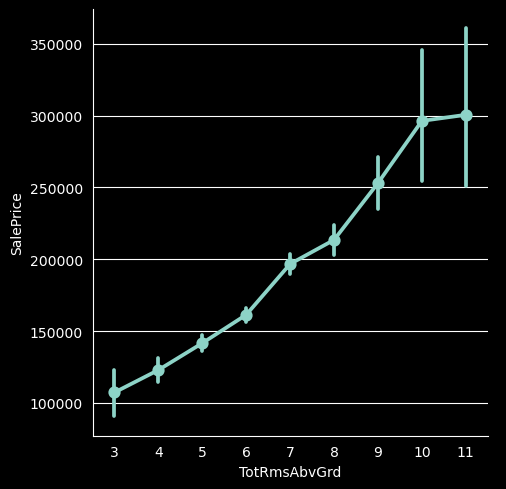

In [84]:
sns.catplot(data=df, x='TotRmsAbvGrd', y='SalePrice', kind='point')
plt.show()

После объединения даже стала хорошая линейная зависимость. Можно спокойно применять *Ordinal-encoding*:

In [85]:
df['TotRmsAbvGrd_Rating'] = 0.0

df.loc[df['TotRmsAbvGrd'] == 3, 'TotRmsAbvGrd_Rating'] = 1
df.loc[df['TotRmsAbvGrd'] == 4, 'TotRmsAbvGrd_Rating'] = 2
df.loc[df['TotRmsAbvGrd'] == 5, 'TotRmsAbvGrd_Rating'] = 2.5
df.loc[df['TotRmsAbvGrd'] == 6, 'TotRmsAbvGrd_Rating'] = 3.5
df.loc[df['TotRmsAbvGrd'] == 7, 'TotRmsAbvGrd_Rating'] = 5
df.loc[df['TotRmsAbvGrd'] == 8, 'TotRmsAbvGrd_Rating'] = 5.5
df.loc[df['TotRmsAbvGrd'] == 9, 'TotRmsAbvGrd_Rating'] = 7
df.loc[df['TotRmsAbvGrd'] == 10, 'TotRmsAbvGrd_Rating'] = 8.5
df.loc[df['TotRmsAbvGrd'] == 11, 'TotRmsAbvGrd_Rating'] = 9

df = df.drop(columns='TotRmsAbvGrd')

## Functional fe
Степень технической исправности и повреждённости дома.

Очень мало сэмплов во всех значениях, кроме *Typ*. При этом график сильно пляшем найти зависимость сложно. Но все дома с повреждениями стабильно дешевле *Typ*.\
Объединю дома с любыми повреждениями во едину и создам новый признак *IsPerfectFunctional*:

In [86]:
df['IsPerfectFunctional'] = (df['Functional'] == 'Typ').astype(int)

df = df.drop(columns='Functional')

## Fireplaces fe
Количество каминов.

Хорошая зависимость. Но очень мало сэмплов со значением 3. Объединю их с соседним значением:

In [87]:
df.loc[df['Fireplaces'] > 2, 'Fireplaces'] = 2

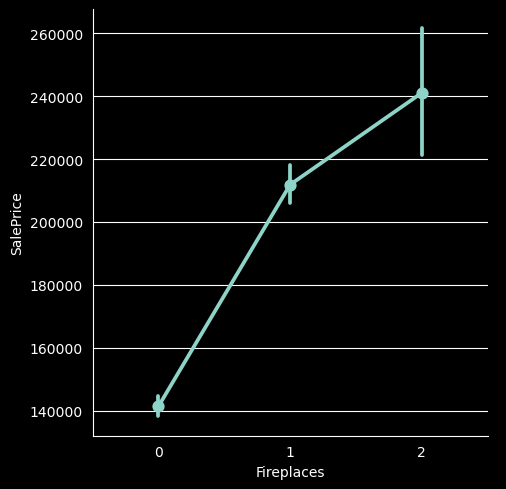

In [88]:
sns.catplot(data=df, x='Fireplaces', y='SalePrice', kind='point')
plt.show()

In [89]:
df['Fireplaces_Rating'] = 0.0

df.loc[df['Fireplaces'] == 0, 'Fireplaces_Rating'] = 1
df.loc[df['Fireplaces'] == 1, 'Fireplaces_Rating'] = 9.5
df.loc[df['Fireplaces'] == 2, 'Fireplaces_Rating'] = 13.5

df = df.drop(columns='Fireplaces')

## FireplaceQu fe
Качество камина.

Мало сэмплов со значениями *Poor* и *Fair*. Попробую объединить:

In [90]:
df.loc[df['FireplaceQu'].isin(['Po', 'Fa']), 'FireplaceQu'] = 'LowQu'

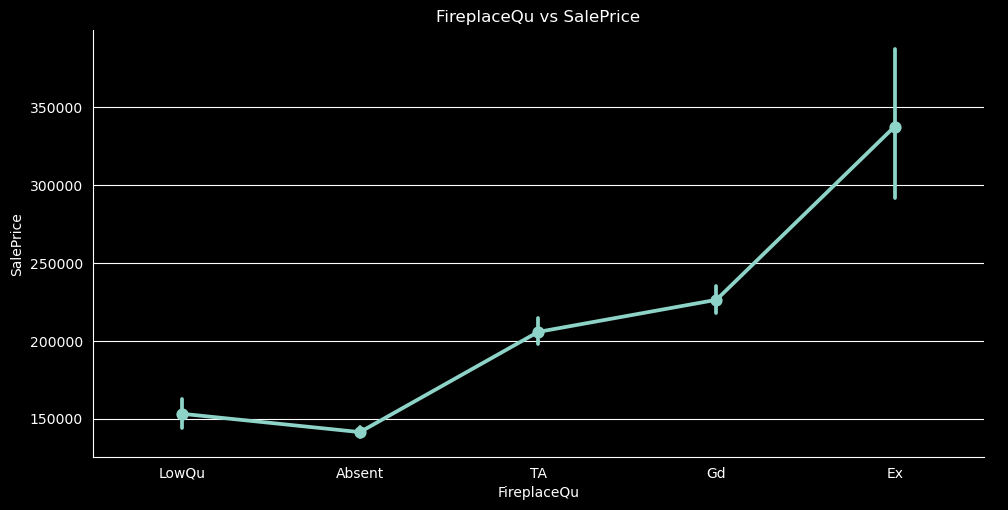

In [91]:
sns.catplot(data=df,
            x='FireplaceQu',
            order=['LowQu', 'Absent', 'TA', 'Gd', 'Ex'],
            y='SalePrice',
            kind='point',
            height=5,
            aspect=2)
plt.title('FireplaceQu vs SalePrice')
plt.show()

Ожидал изначально, что средняя цена домов *LowQu* будет ниже *Absent* за счёт того, что дома старые и камины в них предназначались для
обогрева, а не для красоты. Но результаты оказались иначе. Причём в группе *LowQu* всё равно достаточно мало сэмплов, и кодировать с
помощью *Ordinal-encoding* не лучший вариант.\
В идеале закодировать с помощью *One-hot-encoding*, а здесь сделаю с помощью *Target-encoding*:

In [92]:
df['FireplaceQu_Target'] = 0

fireplacequ_target = df.groupby('FireplaceQu')['SalePrice'].mean()

for fireplacequ, target_mean in fireplacequ_target.items():
    df.loc[df['FireplaceQu'] == fireplacequ, 'FireplaceQu_Target'] = round(target_mean)

df = df.drop(columns='FireplaceQu')

## GarageType fe
Расположение гаража.

Хорошая линейная зависимость в зависимости от типа гаража: *Absent* -> *CarPort* -> *Detchd* -> *Basment* -> *Attchd* -> *Builtin*.\
Но дальше идёт сильное ппадение на *2Types*. Причём таких сэмплов мало. Объединить их с другой группой не вариант, т.к. по смыслу они никуда не подходят.

В идеале применить *One-hot-encoding*, а здесь сделаю *Target-encoding*:

In [93]:
df['GarageType_Target'] = 0

garagetype_target = df.groupby('GarageType')['SalePrice'].mean()

for garagetype, target_mean in garagetype_target.items():
    df.loc[df['GarageType'] == garagetype, 'GarageType_Target'] = round(target_mean)

df = df.drop(columns='GarageType')

## GarageFinish fe
Внутренняя отделка гаража.

Хорошая линейная зависимость, никаких проблем в данных нет.

In [94]:
df['GarageFinish_Rating'] = 0.0

df.loc[df['GarageFinish'] == 'Absent', 'GarageFinish_Rating'] = 1
df.loc[df['GarageFinish'] == 'Unf', 'GarageFinish_Rating'] = 4.5
df.loc[df['GarageFinish'] == 'RFn', 'GarageFinish_Rating'] = 9
df.loc[df['GarageFinish'] == 'Fin', 'GarageFinish_Rating'] = 12

df = df.drop(columns='GarageFinish')

## GarageCars fe
Размер гаража в количестве машин.

Стабильный рост и резкое падение, когда вместимость гаража == 4 машины. У этого значения очень мало сэмплов + все дома старые.\
Обеъединю с ближайшим соседом:

In [95]:
df.loc[df['GarageCars'] > 3, 'GarageCars'] = 3

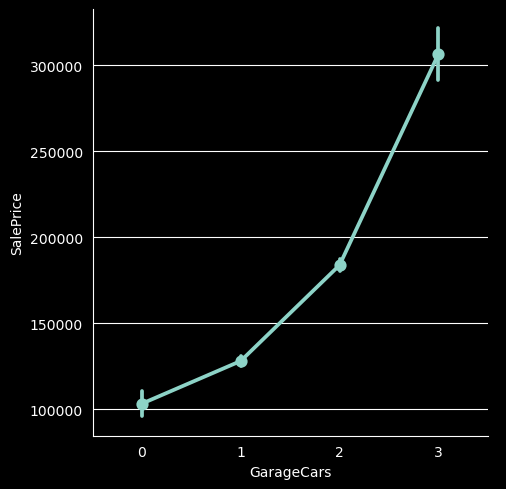

In [96]:
sns.catplot(data=df, x='GarageCars', y='SalePrice', kind='point')
plt.show()

In [97]:
df['GarageCars_Rating'] = 0.0

df.loc[df['GarageCars'] == 0, 'GarageCars_Rating'] = 1
df.loc[df['GarageCars'] == 1, 'GarageCars_Rating'] = 2.5
df.loc[df['GarageCars'] == 2, 'GarageCars_Rating'] = 5.5
df.loc[df['GarageCars'] == 3, 'GarageCars_Rating'] = 13

df = df.drop(columns='GarageCars')

## GarageQual fe
Качество гаража.

Очень мало сэмплов в значениях *Poor*, *Fair*, *Good* и *Excellent*. Если объединить *Poor*+*Fair* и *Good*+*Excellent*, получится достаточная группа для обучения:

In [98]:
df.loc[df['GarageQual'] == 'Ex', 'GarageQual'] = 'Gd'
df.loc[df['GarageQual'] == 'Po', 'GarageQual'] = 'Fa'

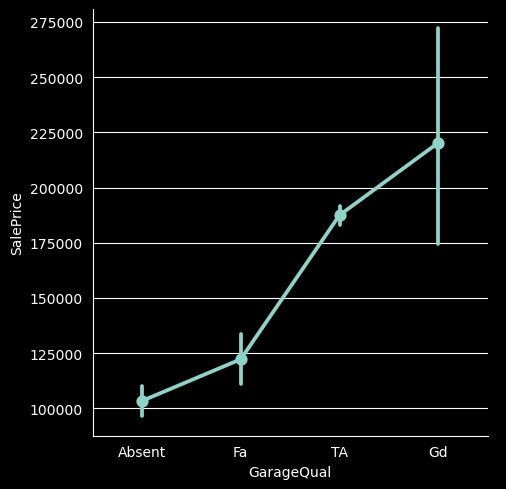

In [99]:
sns.catplot(data=df, x='GarageQual', order=['Absent', 'Fa', 'TA', 'Gd'], y='SalePrice', kind='point')
plt.show()

Пойдёт. Сильное отклонение у *Gd*, но в среднем видно, что цена дома выше.

In [100]:
df['GarageQual_Rating'] = 0.0

df.loc[df['GarageQual'] == 'Absent', 'GarageQual_Rating'] = 1
df.loc[df['GarageQual'] == 'Fa', 'GarageQual_Rating'] = 2.5
df.loc[df['GarageQual'] == 'TA', 'GarageQual_Rating'] = 7.5
df.loc[df['GarageQual'] == 'Gd', 'GarageQual_Rating'] = 10

df = df.drop(columns='GarageQual')

## GarageCond fe
Условия гаража.

Стабильная линейная зависимость: *Absent* -> *Po* -> *Fa* -> *TA*. Дальше резкий и неоъяснимый спад. На *Gd* и *Ex* очень мало сэмплов, даже при объединении их будет недостаточно.\
Объединю *Ex*+*Gd*+*TA* и *Po*+*Fa*:

In [101]:
df.loc[df['GarageCond'].isin(['Ex', 'Gd']), 'GarageCond'] = 'TA'
df.loc[df['GarageCond'] == 'Po', 'GarageCond'] = 'Fa'

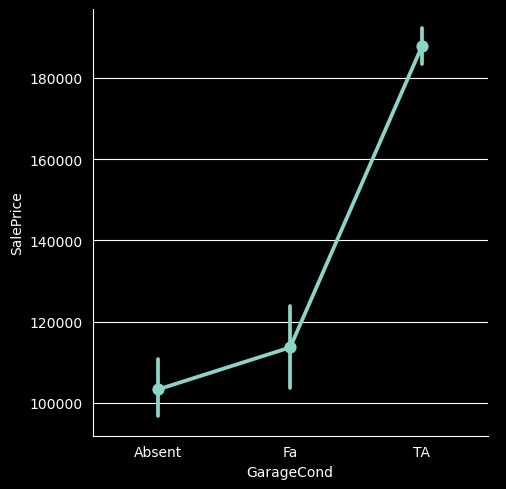

In [102]:
sns.catplot(data=df, x='GarageCond', order=['Absent', 'Fa', 'TA'], y='SalePrice', kind='point')
plt.show()

Хорошая зависимость, можно сохранять:

In [103]:
df['GarageCond_Rating'] = 0

df.loc[df['GarageCond'] == 'Absent', 'GarageCond_Rating'] = 1
df.loc[df['GarageCond'] == 'Fa', 'GarageCond_Rating'] = 2
df.loc[df['GarageCond'] == 'TA', 'GarageCond_Rating'] = 9

df = df.drop(columns='GarageCond')

## PavedDrive fe
Материал дорожки, ведущая от улицы к гаражу или парковке.

Хорошая линейная зависимость, достаточно сэмплов в каждой категории. Можно работать:

In [104]:
df['PavedDrive_Rating'] = 0.0

df.loc[df['PavedDrive'] == 'N', 'PavedDrive_Rating'] = 1
df.loc[df['PavedDrive'] == 'P', 'PavedDrive_Rating'] = 2.5
df.loc[df['PavedDrive'] == 'Y', 'PavedDrive_Rating'] = 7

df = df.drop(columns='PavedDrive')

## WoodDeckSF + OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch fe
Все фичи показывают площадь того или иного участка. *Porch* обозначает участки с верандой. Мультиколлинеарности между ними нет.

Больше интересно, сколько вообще сэмплов имеет тут или иную вернаду, террасу:

In [105]:
(df[['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']] != 0).sum()

WoodDeckSF       699
OpenPorchSF      804
EnclosedPorch    208
3SsnPorch         24
ScreenPorch      116
dtype: int64

Деревянную террасу и открытую веранду имеют, грубо говоря, половина датасета. Остальные веранды имеют малое количество сэмплов. Получаются достаточно разреженные фичи.

Объединю редкие веранды *EnclosedPorch*, *3SsnPorch* и *ScreenPorch* в один признак *RarePorchSF*, а остальное оставлю как есть:

In [106]:
df['RarePorchSF'] = df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch']

df = df.drop(columns=['EnclosedPorch', '3SsnPorch', 'ScreenPorch'])

## PoolArea + PoolQC fe
Показывают характеристики бассейна в доме. Домов с бассейнами в принципе очень мало в датасете — всего 7 штук на 1460 сэмплов!\
Удалю информацию о бассейнах:

In [107]:
df = df.drop(columns=['PoolArea', 'PoolQC'])

## Fence fe
Качество забора.

Почти все сэмплы идут без забора. Достаточное количество сэмплов со значениями *GdPrv* и *MnPrv*. Сэмплов с *MnWw* очень мало, объединю их с *GdWo*:

In [108]:
df.loc[df['Fence'] == 'MnWw', 'Fence'] = 'GdWo'

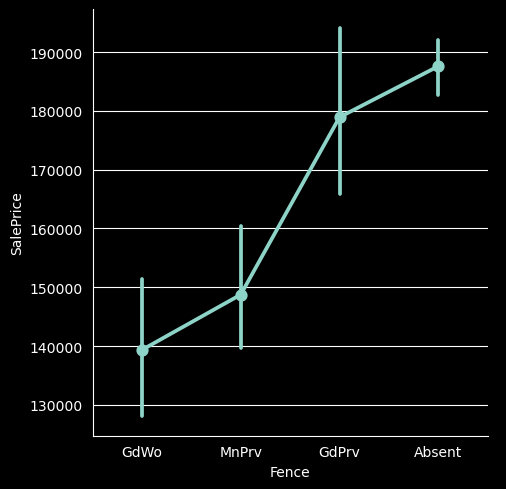

In [109]:
sns.catplot(data=df, x='Fence', order=['GdWo', 'MnPrv', 'GdPrv', 'Absent'], y='SalePrice', kind='point')
plt.show()

Как видно, дома без забора стоят дороже. В данном случае отсутствие забора показывает ценность дома. А у тебя домов, где есть забор, видна хорошая линейная зависимость.\
Можно спокойно кодировать:

In [110]:
df['Fence_Rating'] = 0.0

df.loc[df['Fence'] == 'GdWo', 'Fence_Rating'] = 1
df.loc[df['Fence'] == 'MnPrv', 'Fence_Rating'] = 1.5
df.loc[df['Fence'] == 'GdPrv', 'Fence_Rating'] = 3.5
df.loc[df['Fence'] == 'Absent', 'Fence_Rating'] = 4.5

df = df.drop(columns='Fence')

## MiscFeature + MiscVal fe
Дополнительные объекты, не рассмотренные в других категориях.

Из 1460 сэмплов всего-лишь 54 имеют хоть что-то дополнительное. При этом из этих 54 сэмплов 49 имеют сарай, который вообще не прибавляет никакие ценность. Наоборот, дома с сараем
стоят заметно дешевле.

Удалю данные фичи:

In [111]:
df = df.drop(columns=['MiscFeature', 'MiscVal'])

## MoSold fe
Месяц продажи.

Не имеет зависимости. Удалю:

In [112]:
df = df.drop(columns='MoSold')

## YrSold fe
Год продажи.

Не несёт в себе зависимостей, но служит хорошим плацдармом для высчитывания возраста гаража и дома на момент продажи.\
До этого я уже вычислял возраст гаража. Пора это сделать и для дома:

In [113]:
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

Теперь признаки *YearBuilt*, *YearRemodAdd* и *YrSold* не нужны и можно спокойно их удалять:

In [114]:
df = df.drop(columns=['YearBuilt', 'YearRemodAdd', 'YrSold'])

## SaleType fe
Тип продажи.

Популярные значения только *WD*, *New* и *COD*, остальные значений очень мало. Объединю их в *Other*:

In [115]:
df.loc[~df['SaleType'].isin(['WD', 'New', 'COD']), 'SaleType'] = 'Oth'

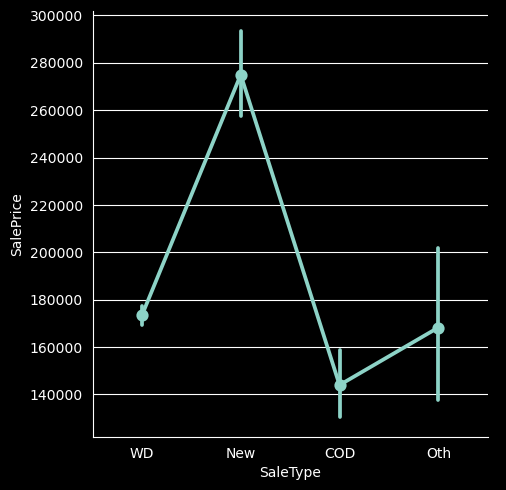

In [116]:
sns.catplot(data=df, x='SaleType', y='SalePrice', kind='point')
plt.show()

Тип продажи *New* действительно должен быть самым дорогим, а *COD* — самым дешёвым. Сделки *WD* и *Oth* похожи по цене + у *Oth* большое отклонение, причём непонятно, должны ли
быть эти сделки дешевле *WD*.\
Лучше всего закодить с помощью *One-hot-encoding*, а здесь сделаю *Target-encoding*:

In [117]:
df['SaleType_Target'] = 0

saletype_target = df.groupby('SaleType')['SalePrice'].mean()

for saletype, target_mean in saletype_target.items():
    df.loc[df['SaleType'] == saletype, 'SaleType_Target'] = round(target_mean)

df = df.drop(columns='SaleType')

## SaleCondition fe
Условия продажи.

Популярные значения только *Normal*, *Abnormal* и *Partial*, остальные значений очень мало. Объединю их в *Other*:

In [118]:
df.loc[~df['SaleCondition'].isin(['Normal', 'Abnorml', 'Partial']), 'SaleCondition'] = 'Other'

In [119]:
pd.crosstab(index=df['SaleCondition'],
            columns=df['SaleCondition'].count(),
            colnames=['Count']
).style.background_gradient(cmap='coolwarm')

Count,1460
SaleCondition,
Abnorml,101
Normal,1198
Other,36
Partial,125


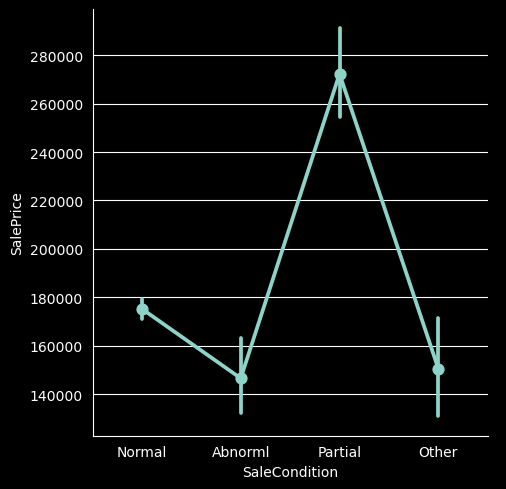

In [120]:
sns.catplot(data=df, x='SaleCondition', y='SalePrice', kind='point')
plt.show()

Срочная продажа *Abnorml* действительно должна быть самой дешёвой, а частичная продажа новостроек *Partial* самой дорогой. *Other* имеет
больше отклонение и не знаю куда его расположить в данном списке.\
Сделаю просто *Target-encoding*:

In [121]:
df['SaleCondition_Target'] = 0

salecondition_target = df.groupby('SaleCondition')['SalePrice'].mean()

for salecondition, target_mean in salecondition_target.items():
    df.loc[df['SaleCondition'] == salecondition, 'SaleCondition_Target'] = round(target_mean)

df = df.drop(columns='SaleCondition')

# Важность признаков с SHAP

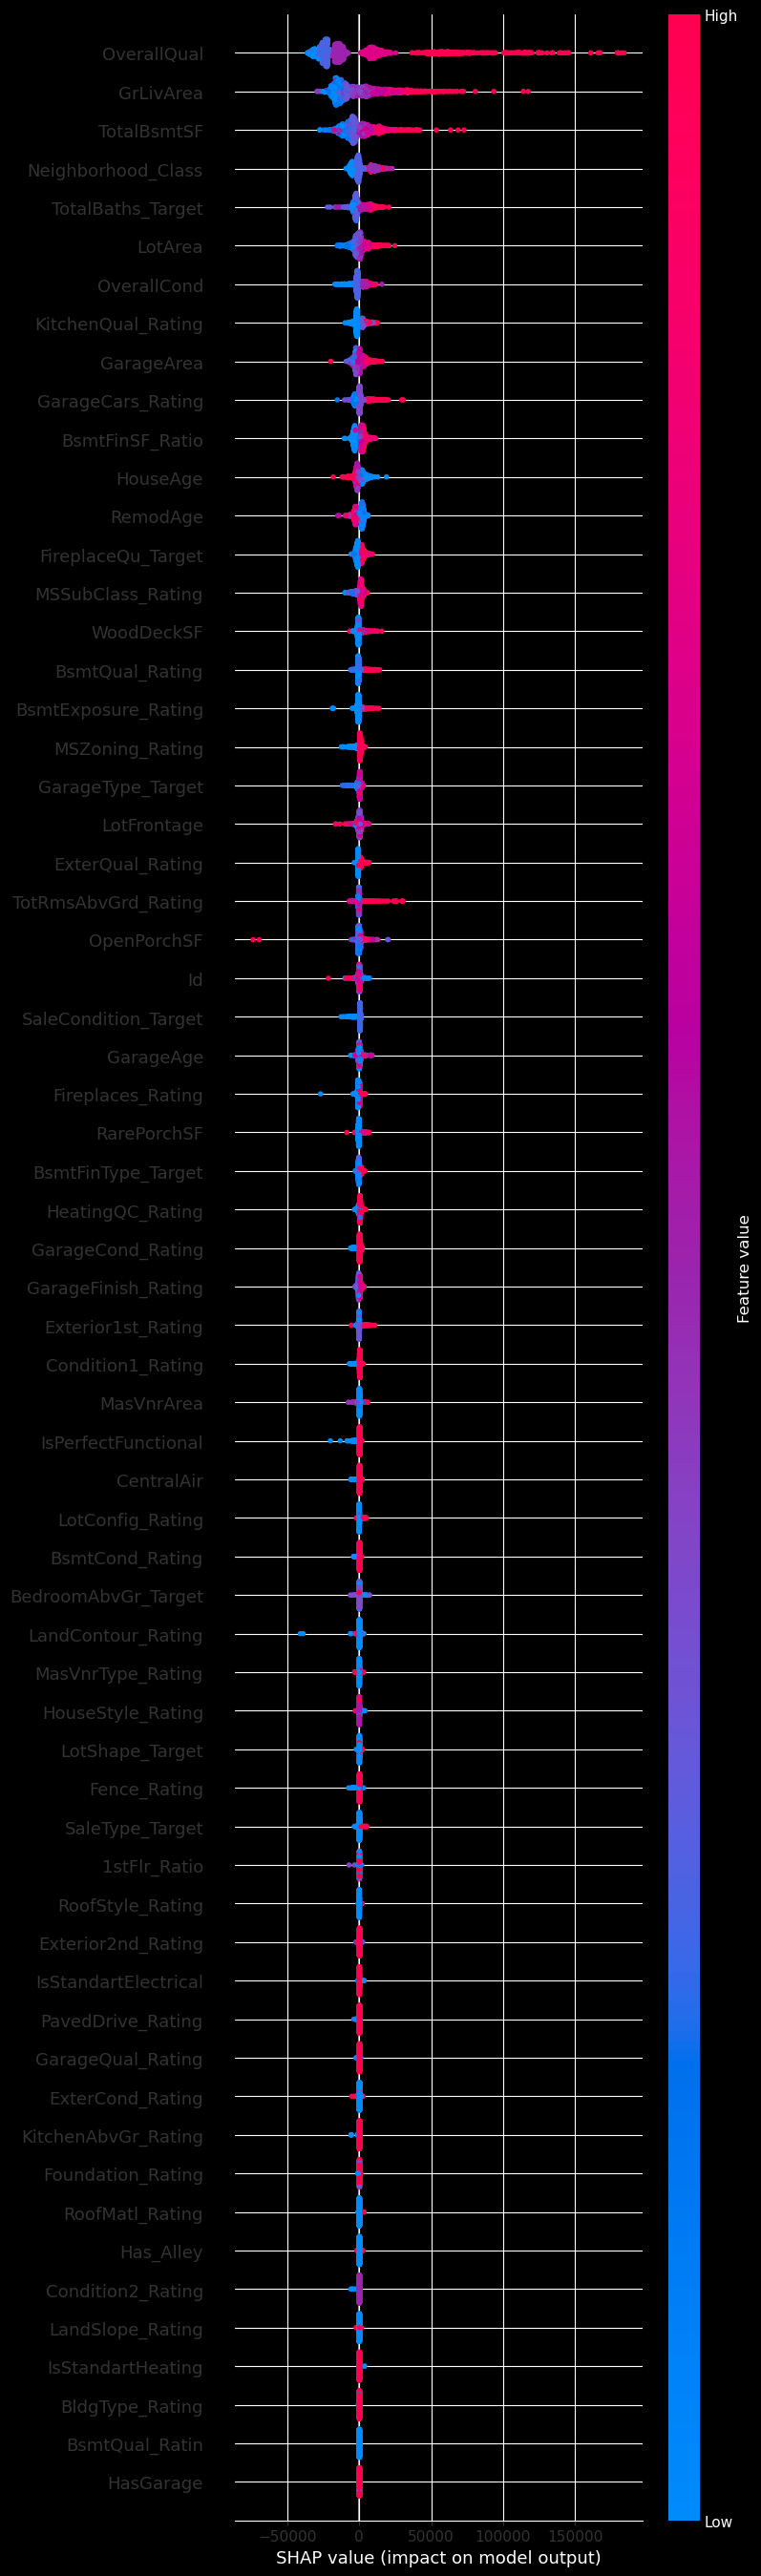

In [122]:
import shap
from xgboost import XGBRegressor

X_train, y_train = df.drop(columns=['SalePrice']), df['SalePrice']

model = XGBRegressor()
model.fit(X_train, y_train)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train, max_display=65)

Исходя из *shap_values*, оставим следующие признаки:
1. OverallQual
2. GrLivArea
3. TotalBsmtSF
4. Neighborhood_Class
5. TotalBaths_Target
6. OverallCond
7. RemodAge
8. LotArea
9. GarageArea
10. BsmtFinSF_Ratio
11. MSSubClass_Rating
12. HouseAge
13. KitchenQual_Rating
14. GarageCars_Rating
15. FireplaceQu_Target
16. BsmtQual_Rating
17. BsmtExplosure_Rating
18. GarageType_Target
19. TotRmsAbvGrd_Rating
20. ExterQual_Rating
21. WoodDeckSF
22. LotFrontage
23. GarageAge
24. BsmtFinType_Rating
25. SaleCondition_Target
26. Fareplaces_Rating
27. Exterior1st_Rating
28. CentralAir
29. LotConfig_Rating
30. Condition1_Rating
31. IsPerfectFunctional

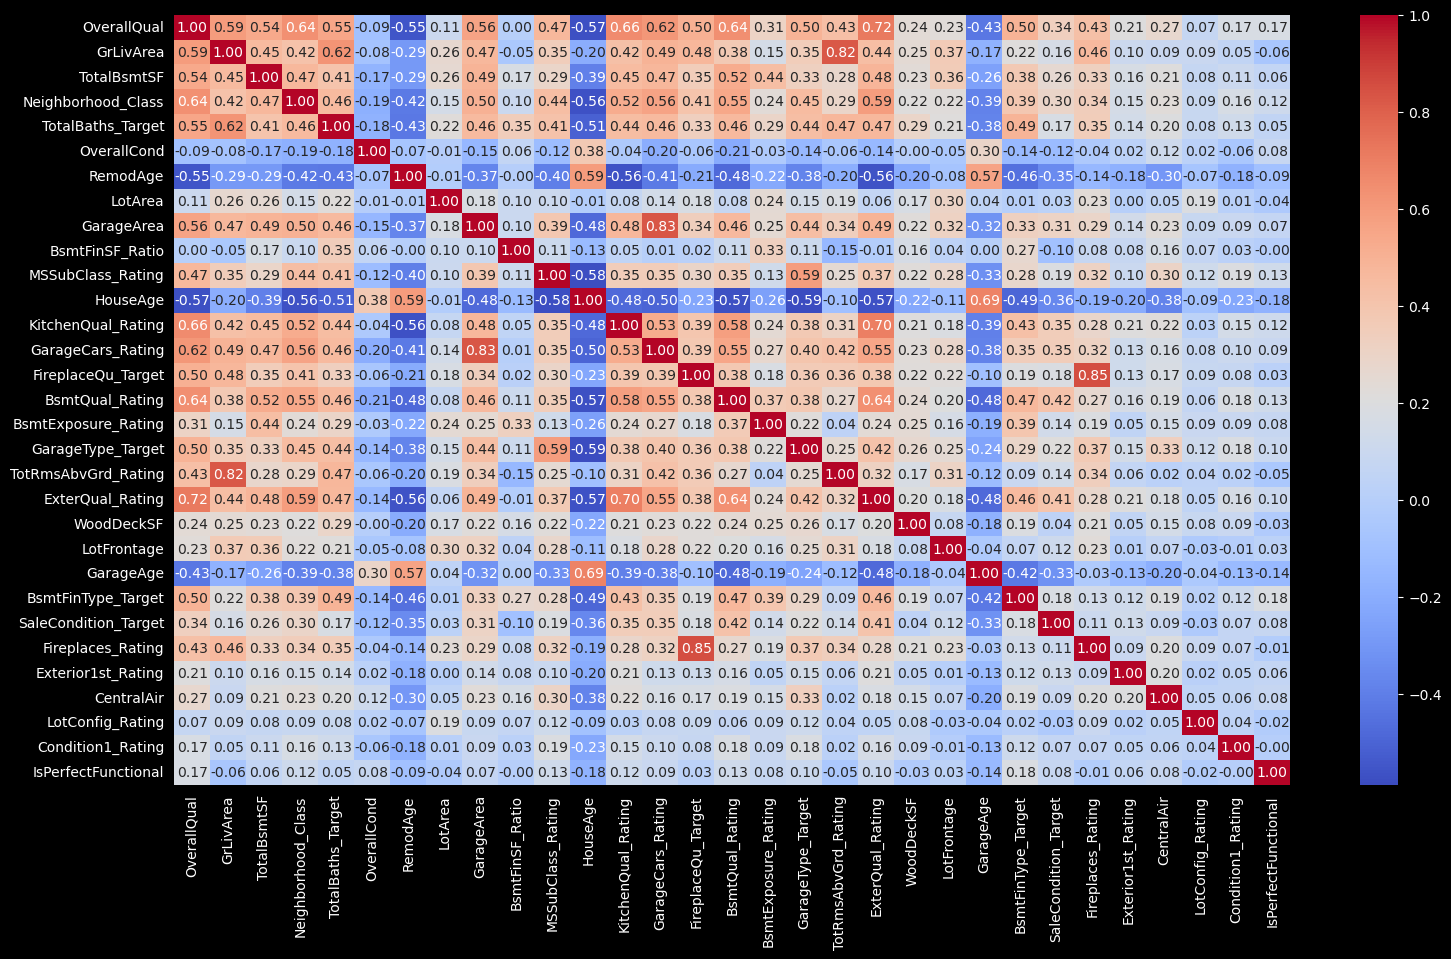

In [123]:
importanest_features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'Neighborhood_Class', 'TotalBaths_Target', 'OverallCond', 'RemodAge', 'LotArea', 'GarageArea',
                        'BsmtFinSF_Ratio', 'MSSubClass_Rating', 'HouseAge', 'KitchenQual_Rating', 'GarageCars_Rating', 'FireplaceQu_Target', 'BsmtQual_Rating',
                        'BsmtExposure_Rating', 'GarageType_Target', 'TotRmsAbvGrd_Rating', 'ExterQual_Rating', 'WoodDeckSF', 'LotFrontage', 'GarageAge', 'BsmtFinType_Target',
                        'SaleCondition_Target', 'Fireplaces_Rating', 'Exterior1st_Rating', 'CentralAir', 'LotConfig_Rating', 'Condition1_Rating', 'IsPerfectFunctional']

plt.figure(figsize = (18,10))
sns.heatmap(data=df[importanest_features].corr(),
            annot=True,
            cmap='coolwarm',
            linewidths=0,
            fmt='.2f')
plt.show()

В принципе, корряляции выше |0.85| не вижу между значимыми фичами. Оставлю все для лучшего предикта.

И ещё проверю значимость SHAP с помощью другой модели:

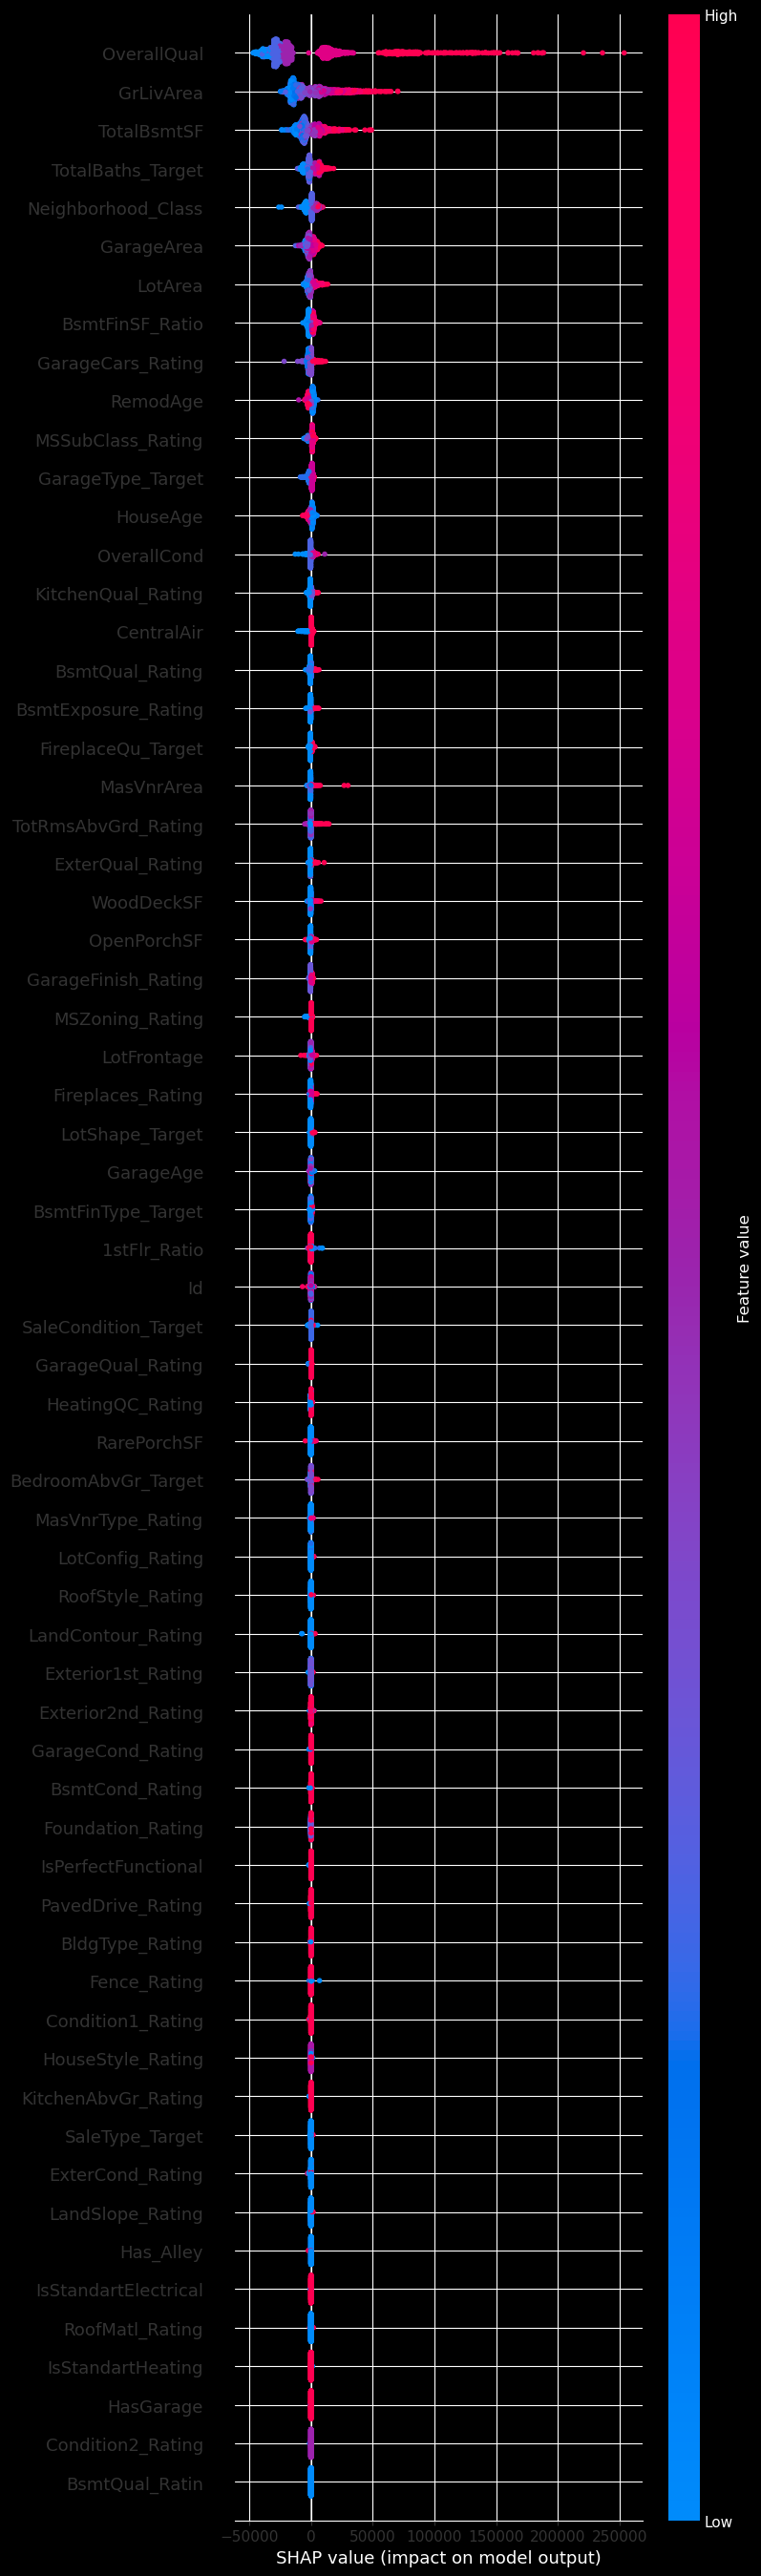

In [124]:
from sklearn.ensemble import RandomForestRegressor

X_train, y_train = df.drop(columns=['SalePrice']), df['SalePrice']

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train, max_display=65)

Важные признаки практически совпадают. Оставлю изначальный набор признаков из 31 фичи для обучения моделей.